# Test 1, Part B: Volume, ticket profile, and two operations claims

Part A assessed concepts. Part B assesses whether you can apply them without step-by-step direction: choose a representation, find the main structure in a small operational dataset, then test two claims about that structure and say what the data can and cannot support.

This part is worth 23 points. It opens on publication, Wednesday, September 23, and is due Monday, September 28 at 11:59 p.m. Central for all students. Work individually. Submit one `.ipynb` notebook, as for homework.

**Resources.** Open book, open notes, open documentation. You may use LLM assistance for understanding and debugging under the homework policy: the explanations you submit must be your own, you must be able to explain the work, and you must disclose material assistance at the end.

**Grading rule.** The interpretation prompts must use the numbers your notebook prints. Generic answers that could describe any dataset, and answers whose numbers do not match your outputs, receive no credit. Code earns credit only through the decisions it shows: the representation, the number of components, the statistic, and the null model. Code that runs earns nothing on its own.

**Time.** Designed for about two hours of focused work. No method here is new to the course, and the setup supplies helpers for display and grouping. Parts 3 and 4 carry 12 of the 23 points, so budget your time for them. If you are well past three hours, stop, write down what you have, and submit.

## The case

Rolling Kitchen operates six food trucks in one city. Each truck serves a lunch window and a dinner window on working days. The operations lead has two beliefs about the August 2026 service windows and wants to know whether the recorded data support them:

1. **Dinner windows run at higher volume than lunch windows.** Based on last summer's peak weeks, the lead currently staffs dinner windows for about 40 percent more orders than lunch windows.
2. **Trucks in the north district run at higher volume than trucks in the south district.**

"Volume" is not a single column. Part of your task is to decide how the seven recorded measurements represent it.

**Provenance.** The file covers the six trucks over the twenty working days from August 3 through August 28, 2026, one row per truck per day per window. Nine windows with a recorded point-of-sale outage were removed before the file was prepared. The operator assigned trucks to districts; the documentation does not say how or whether trucks ever move between districts. There is no information about weather, events, menu changes, or staffing.

| Column | Description | Units |
| --- | --- | --- |
| `window_id` | Row label | - |
| `truck` | Truck identifier, T1 to T6 | - |
| `district` | Operating district, `north` or `south` | - |
| `date` | Service date | ISO date |
| `window` | `lunch` or `dinner` | - |
| `orders` | Orders completed in the window | count |
| `items` | Items sold | count |
| `revenue_usd` | Window revenue | US dollars |
| `avg_ticket_usd` | Average order value | US dollars |
| `queue_peak` | Longest observed queue | customers |
| `prep_minutes` | Average preparation time per order | minutes |
| `card_share` | Share of orders paid by card | proportion |

## Setup

The setup loads the file, prints a summary, and defines three helpers you may use anywhere below. Read the summary, but do not spend time on further exploration; the assessed work starts at Part 1.

In [86]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from sklearn.decomposition import PCA

DATA_URL = (
    "https://raw.githubusercontent.com/olearydj/INSY7130/"
    "main/tests/test1/data/service-windows.csv"
)
data_candidates = [
    Path("data/service-windows.csv"),
    Path("content/tests/test1/data/service-windows.csv"),
]
data_source = next((path for path in data_candidates if path.is_file()), DATA_URL)
FEATURES = [
    "orders", "items", "revenue_usd", "avg_ticket_usd",
    "queue_peak", "prep_minutes", "card_share",
]
windows = pd.read_csv(data_source).set_index("window_id")
measurements = windows[FEATURES]

print("Rows and columns:", windows.shape)
print(windows["window"].value_counts().to_dict(), windows["district"].value_counts().to_dict())
display(measurements.describe().round(2))
display(measurements.corr().round(2))

Rows and columns: (231, 11)
{'lunch': 117, 'dinner': 114} {'south': 117, 'north': 114}


,orders,items,revenue_usd,avg_ticket_usd,queue_peak,prep_minutes,card_share
count,231.00,231.00,231.00,231.00,231.00,231.00,231.00
mean,60.03,103.85,733.25,12.30,5.52,4.89,0.64
std,17.81,30.94,247.00,2.41,3.37,1.17,0.08
min,12.00,13.00,116.08,6.57,0.00,2.13,0.44
25%,48.00,83.00,552.78,10.68,3.00,4.03,0.58
50%,61.00,105.00,738.91,12.18,5.00,4.83,0.64
75%,73.00,127.00,888.01,13.93,8.00,5.69,0.69
max,105.00,179.00,1444.17,19.38,14.00,8.59,0.88


,orders,items,revenue_usd,avg_ticket_usd,queue_peak,prep_minutes,card_share
orders,1.00,0.94,0.79,-0.17,0.87,-0.36,-0.13
items,0.94,1.00,0.86,0.04,0.82,-0.18,0.03
revenue_usd,0.79,0.86,1.00,0.43,0.68,0.16,0.32
avg_ticket_usd,-0.17,0.04,0.43,1.00,-0.15,0.84,0.73
queue_peak,0.87,0.82,0.68,-0.15,1.00,-0.33,-0.16
prep_minutes,-0.36,-0.18,0.16,0.84,-0.33,1.00,0.70
card_share,-0.13,0.03,0.32,0.73,-0.16,0.70,1.00


The helpers below are supplied so that display and grouping do not cost you time. They contain no decisions.

In [87]:
def summarize_pca(fitted, feature_names):
    """Return (loadings, variance_summary) tables for a fitted PCA."""
    names = [f"PC{i + 1}" for i in range(fitted.n_components_)]
    loadings = pd.DataFrame(fitted.components_.T, index=feature_names, columns=names)
    variance_summary = pd.DataFrame(
        {
            "Eigenvalue (component variance)": fitted.explained_variance_,
            "Variance retained (%)": 100 * fitted.explained_variance_ratio_,
            "Cumulative retained (%)": 100 * fitted.explained_variance_ratio_.cumsum(),
        },
        index=names,
    )
    return loadings, variance_summary


def plot_scores(scores, labels, x="PC1", y="PC2", xlabel=None, ylabel=None):
    """Scatter two score columns, marking each row by a label Series (for example windows["window"])."""
    fig, ax = plt.subplots(figsize=(6, 4.5))
    for value, marker in zip(sorted(labels.unique()), ("o", "^", "s", "D")):
        mask = labels == value
        ax.scatter(scores.loc[mask, x], scores.loc[mask, y], marker=marker, alpha=0.7, label=str(value))
    ax.axvline(0, color="gray", lw=0.5)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel or y)
    ax.legend(title=labels.name)
    plt.tight_layout()
    plt.show()


def split_groups(values, labels, first, second):
    """Return (first_array, second_array): the values whose label equals first, then second."""
    return values[labels == first].to_numpy(), values[labels == second].to_numpy()

## Part 1: Represent volume (5 points)

Decide how to represent the seven measurements before reducing them, fit PCA, and identify what its leading components measure. The decisions are yours; the mechanics are not new.

Your work must show:

- **1a.** Whether you standardize the columns, with evidence for the decision. Fit PCA to `measurements` and to a standardized copy, call `summarize_pca` on each, and compare the two PC1 loadings.
- **1b.** Your choice of how many components to keep, with the reason, using the variance summary from your chosen representation.
- **1c.** The loadings of the first two components and a one-line operational name for each, in Rolling Kitchen's terms.
- **1d.** One figure that shows the structure you found. `plot_scores(scores, windows["window"])` is one acceptable choice.

Save the component scores in a DataFrame named `scores` with columns `PC1`, `PC2`, and so on, indexed by `window_id`, and orient PC1 so that a larger score means more volume: if the `orders` loading on PC1 is negative, negate that column of `scores`. Later parts use it.

In [88]:
# 1a. Standardize, fit PCA to both frames, and compare the PC1 loadings.
x_raw = measurements.copy()
x_standardized = (measurements - measurements.mean()) / measurements.std(ddof = 0) # standardizing the measurements

pca_raw = PCA() # fitting PCA to undstandardized data
pca_raw.fit(x_raw)

pca_standardized = PCA() # fitting PCA to standardized data
pca_standardized.fit(x_standardized)

raw_loadings, raw_variance = summarize_pca(pca_raw, FEATURES)
standardized_loadings, standardized_variance = summarize_pca(pca_standardized, FEATURES)

print('The standard deviation of the original measurement')
display(measurements.std().round(2))
print('The PC1 loadings without standardization')
display(raw_loadings[["PC1"]].round(3))
print('The PC1 loadings with standardization')
display(standardized_loadings[["PC1"]].round(3))
print('The Variance summary for standardized PCA')
display(standardized_variance.round(2))

The standard deviation of the original measurement


,0
orders,17.81
items,30.94
revenue_usd,247.00
avg_ticket_usd,2.41
queue_peak,3.37
prep_minutes,1.17
card_share,0.08


The PC1 loadings without standardization


,PC1
orders,0.057
items,0.107
revenue_usd,0.993
avg_ticket_usd,0.004
queue_peak,0.009
prep_minutes,0.001
card_share,0.000


The PC1 loadings with standardization


,PC1
orders,0.523
items,0.508
revenue_usd,0.432
avg_ticket_usd,-0.063
queue_peak,0.488
prep_minutes,-0.187
card_share,-0.066


The Variance summary for standardized PCA


,Eigenvalue (component variance),Variance retained (%),Cumulative retained (%)
PC1,3.56,50.65,50.65
PC2,2.72,38.70,89.35
PC3,0.33,4.69,94.04
PC4,0.20,2.91,96.96
PC5,0.14,2.02,98.98
PC6,0.05,0.78,99.76
PC7,0.02,0.24,100.00


The variance summary


,Eigenvalue (component variance),Variance retained (%),Cumulative retained (%)
PC1,3.56,50.65,50.65
PC2,2.72,38.70,89.35
PC3,0.33,4.69,94.04
PC4,0.20,2.91,96.96
PC5,0.14,2.02,98.98
PC6,0.05,0.78,99.76
PC7,0.02,0.24,100.00


The first two component loadings


,PC1,PC2
orders,0.523,-0.017
items,0.508,0.104
revenue_usd,0.432,0.324
avg_ticket_usd,-0.063,0.574
queue_peak,0.488,-0.030
prep_minutes,-0.187,0.525
card_share,-0.066,0.527


The number of components retained is 2
The cumulative variance retained is 89.35 %
The oriented PC1 and PC2 loadings


,PC1,PC2
orders,0.523,-0.017
items,0.508,0.104
revenue_usd,0.432,0.324
avg_ticket_usd,-0.063,0.574
queue_peak,0.488,-0.030
prep_minutes,-0.187,0.525
card_share,-0.066,0.527


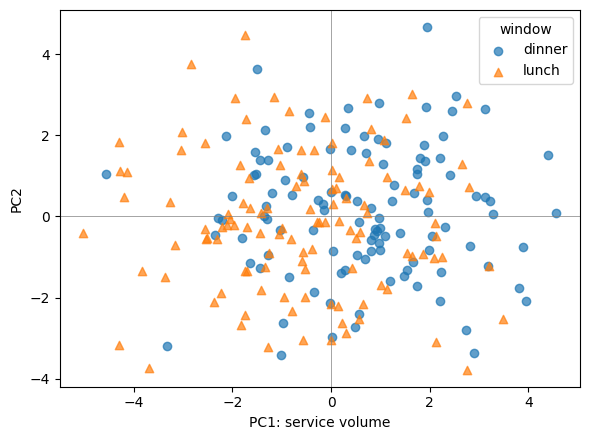

In [89]:
# 1b-1d. Retained variance and your k, the first two loadings, the oriented scores, and the figure.
pca = pca_standardized
loadings = standardized_loadings.copy()
variance_summary = standardized_variance

print("The variance summary")
display(variance_summary.round(2))
print("The first two component loadings")
display(loadings[['PC1', 'PC2']].round(3))

k = np.argmax (pca.explained_variance_ratio_.cumsum() >= 0.80) +1
print("The number of components retained is", k )
print("The cumulative variance retained is", round(100*pca.explained_variance_ratio_[:k].sum(), 2),"%")

score_array = pca.transform(x_standardized) # Creating scores
scores = pd.DataFrame(score_array[:, :k], index = windows.index, columns= [f"PC{i + 1}" for i in range(k)])

if loadings.loc["orders", "PC1"] < 0:  # Orient scores
  scores ["PC1"] = -scores ["PC1"]
  loadings ["PC1"] = -loadings["PC1"]

print("The oriented PC1 and PC2 loadings")
display(loadings [["PC1", "PC2"]].round(3))

plot_scores(scores, windows["window"], x="PC1", y= "PC2", xlabel= "PC1: service volume", ylabel="PC2") # figure

## Part 2: Test the two claims (6 points)

Use your volume score to test each of the operations lead's claims. `split_groups(values, labels, first, second)` returns the two arrays that a two-sample SciPy call expects.

Your work must show:

- **2a.** A one-number statistic that represents a claim, written as a two-argument function and stated before any test is run, with its sign convention. A signed difference of group means is acceptable; another statistic is acceptable if you say why it represents the claim better.
- **2b.** The null model in one sentence for each claim: what is being shuffled, and what that assumes.
- **2c.** Three SciPy permutation tests, each with 5,000 resamples, a two-sided alternative, and random seed 7130, printing the observed statistic and the simulated p-value for each: claim 1 on your volume score (dinner minus lunch), claim 2 on your volume score (north minus south), and claim 2 on `revenue_usd`. Write a small function or repeat the call, whichever you prefer. Revenue is the figure the operations lead sees in the monthly summary, so the two claim-2 results are what you will reconcile in Part 3.
- **2d.** Two 95 percent bootstrap intervals (5,000 resamples, seed 7130, percentile method), printed: the percent difference in mean `orders`, dinner relative to lunch, which is the quantity behind the lead's staffing figure; and the difference in mean `revenue_usd`, north minus south.

Claim 1: Null model
Under the null hypothesis, the lunch and dinner labels are interchangeable; rearranging those labels depicts a scenario in which the mean volume score is unrelated to the type of service window.

claim 2: Volume null model:
Under the null hypothesis, the North and South district labels are interchangeable; rearranging them depicts a scenario in which the district has no correlation with the average service volume.

Claim 2: Revenue null model
Under the null hypothesis, the North/South district labels are interchangeable; rearranging them depicts a scenario in which district and mean revenue are unrelated.

In [90]:
# 2a-2c. Statistic function and the three permutation results. State each null model in a comment or a short markdown cell.
def mean_difference (x, y):
  return np.mean(x) - np.mean(y)

dinner_vol, lunch_vol = split_groups (scores ["PC1"], windows ["window"], "dinner", "lunch") # claim 1 ( Dinner volume - Lunch volume)
claim_1 = stats.permutation_test((dinner_vol, lunch_vol), mean_difference, permutation_type= "independent", alternative="two-sided", n_resamples=5000, random_state=7130)

print("CLAIM 1: Dinner volume - Lunch volume")
print("observed statistics is", round(claim_1.statistic, 4))
print("simulated p-value is", round(claim_1.pvalue, 4))

north_vol, south_vol = split_groups (scores ["PC1"], windows ["district"], "north", "south") # claim 2 ( North volume - South volume)
claim_2 = stats.permutation_test((north_vol, south_vol), mean_difference, permutation_type= "independent", alternative="two-sided", n_resamples=5000, random_state=7130)

print("CLAIM 2: North volume - South volume")
print("observed statistics is", round(claim_2.statistic, 4))
print("simulated p-value is", round(claim_2.pvalue, 4))

north_rev, south_rev = split_groups (windows ["revenue_usd"], windows ["district"], "north", "south") # claim 3 ( North revenue - South revenue)
claim_3 = stats.permutation_test((north_rev, south_rev), mean_difference, permutation_type= "independent", alternative="two-sided", n_resamples=5000, random_state=7130)

print("CLAIM 3: North revenue - South revenue")
print("observed statistics is", round(claim_3.statistic, 4))
print("simulated p-value is", round(claim_3.pvalue, 4))

CLAIM 1: Dinner volume - Lunch volume
observed statistics is 1.2465
simulated p-value is 0.0004
CLAIM 2: North volume - South volume
observed statistics is -0.8475
simulated p-value is 0.0004
CLAIM 3: North revenue - South revenue
observed statistics is 24.137
simulated p-value is 0.4647


In [91]:
# 2d. Bootstrap intervals: percent difference in orders (dinner relative to lunch) and revenue difference (north minus south).
dinner_orders, lunch_orders = split_groups (windows["orders"], windows ["window"], "dinner", "lunch")

def percent_difference (dinner, lunch, axis= -1):
  return (np.mean(dinner, axis=axis) / np.mean(lunch, axis=axis) - 1) * 100

boot_orders = stats.bootstrap((dinner_orders, lunch_orders), percent_difference, paired=False,confidence_level=0.95,n_resamples=5000,method= "percentile", random_state=7130)
print("The 95% bootstrap confidence interval for percent difference in mean orders")
print("Dinner relative to lunch")
print(round(boot_orders.confidence_interval.low, 2),"%", "to", round(boot_orders.confidence_interval.high, 2), "%")

def mean_difference (a, b, axis= -1):
  return np.mean(a, axis=axis) - np.mean(b, axis=axis)

boot_revenue = stats.bootstrap((north_rev, south_rev), mean_difference, paired=False,confidence_level=0.95,n_resamples=5000,method= "percentile", random_state=7130)
print("The 95% bootstrap confidence interval for mean difference")
print("North minus south")
print("$" + str(round(boot_revenue.confidence_interval.low, 4)), "to", "$" + str(round(boot_revenue.confidence_interval.high, 4)))

The 95% bootstrap confidence interval for percent difference in mean orders
Dinner relative to lunch
11.85 % to 29.55 %
The 95% bootstrap confidence interval for mean difference
North minus south
$-40.2062 to $88.086


## Part 3: Interpretation (9 points)

Answer each prompt in a short paragraph using the numbers your notebook printed.

**3a. Representation (3 points).** State the first-component loadings from your chosen representation and what PC1 measures. State the retained variance at your chosen number of components. Then say what PC1 measured when the columns were not standardized, and why that would have been the wrong representation of volume.

> Represenataion : Because the variables' scales varied significantly, I standardized them. Standardized PC1 loadings were orders 0.523, items 0.508, revenue 0.432, average ticket -0.063, queue peak 0.488, prep minutes -0.187, and card share -0.066. This indicates that PC1 represents service volume, while keeping two PCs explains 89.35% of the variance; without standardization, PC1 was dominated by revenue (loading 0.993), making it a poor overall volume measure.

**3b. Claim 1 (3 points).** Report the observed volume statistic with its direction and the simulated p-value under your null model. Then report the interval for the percent difference in orders and say whether the 40 percent staffing figure is consistent with it. Give one bounded conclusion the evidence supports and one conclusion it does not support. Do not describe the p-value as the probability that the claim is false.

> Claim 1 : The suggested 40% staffing increase is inconsistent with the 95% bootstrap interval, which indicates that dinner orders are 11.85% to 29.55% higher than lunch (difference = 1.2465, p = 0.0004). The evidence supports higher average dinner demand but does not prove that every dinner period is busier or that dinner itself causes the increase.

**3c. Claim 2 (3 points).** Report the observed statistic and simulated p-value for your volume score and for revenue. Tell the operations Lead, in plain language, what the volume result establishes about the belief and why the revenue result differs. Then use the revenue interval to state the range of revenue differences the data are consistent with, and explain why the revenue result's "no evidence of a difference" is not the same as "no difference."

> Claim 2 and 3: North had significantly lower overall volume than South (-0.8475, p = 0.0004), but its revenue difference was only $24.137 (p = 0.4647) with a 95% CI of (-40.21 USD to 88.09 USD), so operational volume differs while revenue does not show clear evidence of a difference because revenue also reflects transaction value , and "no evidence of a revenue difference" does not mean the revenue are identical.

## Part 4: Bounded claim, reproducibility, and disclosure (3 points)

**4a.** In two or three sentences, state the scope of what this analysis can claim about Rolling Kitchen's operations. Name what the file covers, what was removed, and one thing the provenance leaves unknown that limits the claim.

>The results should not be extrapolated to all rolling kitchen operations or interpreted as causal because the provenance does not establish a representative random sample. This analysis only describes the rolling kitchen service windows included in the provided file, following the dataset's specified exclusions.

Restart the runtime and run all cells in order before submitting. Keep the outputs and check that the numbers in your answers match them.

| Evaluation | Points |
| --- | ---: |
| Part 1: representation decision, k, component naming, figure | 5 |
| Part 2: statistic, null models, three permutation results, two intervals | 6 |
| Part 3: interpretation tied to your outputs | 9 |
| Part 4: bounded claim, reproducibility, and assistance disclosure | 3 |
| **Total** | **23** |

**Assistance disclosure:** Identify material assistance, including any LLM use, and how you checked it. Write `None` if you received no material assistance.

> I used ChatGPT to get clarity on how to code 1b to 1d especially. I also used paraphrasing tools to restructure my interpretations.

**Optional, ungraded feedback:** Approximately how much active time did you spend, excluding breaks? Which part required the most effort, and was anything unclear?

> 153 minutes active time. Question 1b to 1d required most effort, creating scores and oriented PC1 was unclear.